# SIH26168 Colab Training — AVNetLite on IO-VNBD
Target 95% accuracy (<5% drift). Run all cells in order. T4 GPU recommended.

In [1]:
!git clone https://github.com/Himanshu121865/sih26168.git
%cd sih26168
!pip install torch --index-url https://download.pytorch.org/whl/cu121 -q
!pip install pandas scipy onnx onnxruntime onnxscript loguru matplotlib scikit-learn -q
import torch; print(torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")

Cloning into 'sih26168'...
remote: Enumerating objects: 79, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 79 (delta 28), reused 66 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (79/79), 2.10 MiB | 23.84 MiB/s, done.
Resolving deltas: 100% (28/28), done.
/content/sih26168
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 102.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 21.9 MB/s eta 0:00:00
True Tesla T4


In [2]:
!python python/download_iovnbd.py --subset Sync
!ls -lh data/iovnbd/*.zip
!python python/preprocess.py --subset 1h --window 200 --stride 10 --hz 100
!ls -lh data/processed/ && cat python/scaler.json | head -20

[dl] https://media.githubusercontent.com/media/onyekpeu/IO-VNBD/master/Synchronised%20V%20abd%20S%20datasets.zip -> data/iovnbd/Synchronised V abd S datasets.zip (203.6 MB)
  99.8%
[done] data/iovnbd/Synchronised V abd S datasets.zip 203606286 bytes
[unzip] data/iovnbd/Synchronised V abd S datasets.zip -> data/iovnbd/
[unzip] done [PosixPath('data/iovnbd/Synchronised V abd S datasets/Uncategorised IOVNB Dataset'), PosixPath('data/iovnbd/Synchronised V abd S datasets/Categorised IOVNB Dataset')]
[ok] download_iovnbd done
-rw-r--r-- 1 root root 195M Aug 29 21:08 'data/iovnbd/Synchronised V abd S datasets.zip'
[preprocess] 3 S files, window=200 stride=10 hz=100
[split] train files 2 val files 1 (by trajectory, seed 26168)
[ok] M (Driver B)/S-M.csv: T=105974->617597 windows=61740 stationary=1600 median_dt=51.0ms
[ok] S1/S-S1.csv: T=51746->517450 windows=51726 stationary=4859 median_dt=100.0ms
[ok] S2/S-S2.csv: T=93876->920111 windows=91992 stationary=11313 median_dt=100.0ms
[concat] train 

In [3]:
# Retrain with P0 fixes: ZUPT (preprocess now flags 5.7% stationary), random-yaw + NLL
!PYTHONPATH=. python python/train_avnet.py --epochs 20 --batch 128 --lr 1e-3 --device cuda --augment-yaw --lambda-nll 0.1
!ls -lh experiments/checkpoints/

[train] device cuda epochs 20 batch 128 lr 0.001 augment_yaw=True lambda_nll=0.1
[dataset] npy mode data/processed/train_windows.npy
[dataset] npy mode data/processed/val_windows.npy
[data] train 113466 val 91992
[model] params 460,136
[epoch 1/20] train loss 1.0405 (mse 0.9990) val MSE 1.5089 lr 1.00e-03 11.4s
  [save] experiments/checkpoints/model_avnet_stage1.p best 1.5089
[epoch 2/20] train loss 0.7916 (mse 0.7401) val MSE 1.4812 lr 1.00e-03 10.2s
  [save] experiments/checkpoints/model_avnet_stage1.p best 1.4812
[epoch 3/20] train loss 0.7226 (mse 0.6694) val MSE 1.4489 lr 1.00e-03 9.8s
  [save] experiments/checkpoints/model_avnet_stage1.p best 1.4489
[epoch 4/20] train loss 0.6832 (mse 0.6294) val MSE 1.4715 lr 1.00e-03 10.0s
[epoch 5/20] train loss 0.6524 (mse 0.5982) val MSE 1.4656 lr 1.00e-03 10.3s
[epoch 6/20] train loss 0.6304 (mse 0.5760) val MSE 1.4307 lr 1.00e-03 9.5s
  [save] experiments/checkpoints/model_avnet_stage1.p best 1.4307
[epoch 7/20] train loss 0.6043 (mse 0.55

[dataset] npy mode data/processed/val_windows.npy
[mse] val MSE 1.4188 RMSE 1.1911 m/s
/content/sih26168/python/eval_drift.py:82: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  xb = torch.from_numpy(X_seg[i:i+64])
[eval] segment 600 windows (60s) total_dist 188.1m
  naive final 16.4m drift 8.7%
  AI final 40.8m drift 21.7%
  AI+map final 24.5m drift 13.0%
[plot] saved reports/drift_plot.png


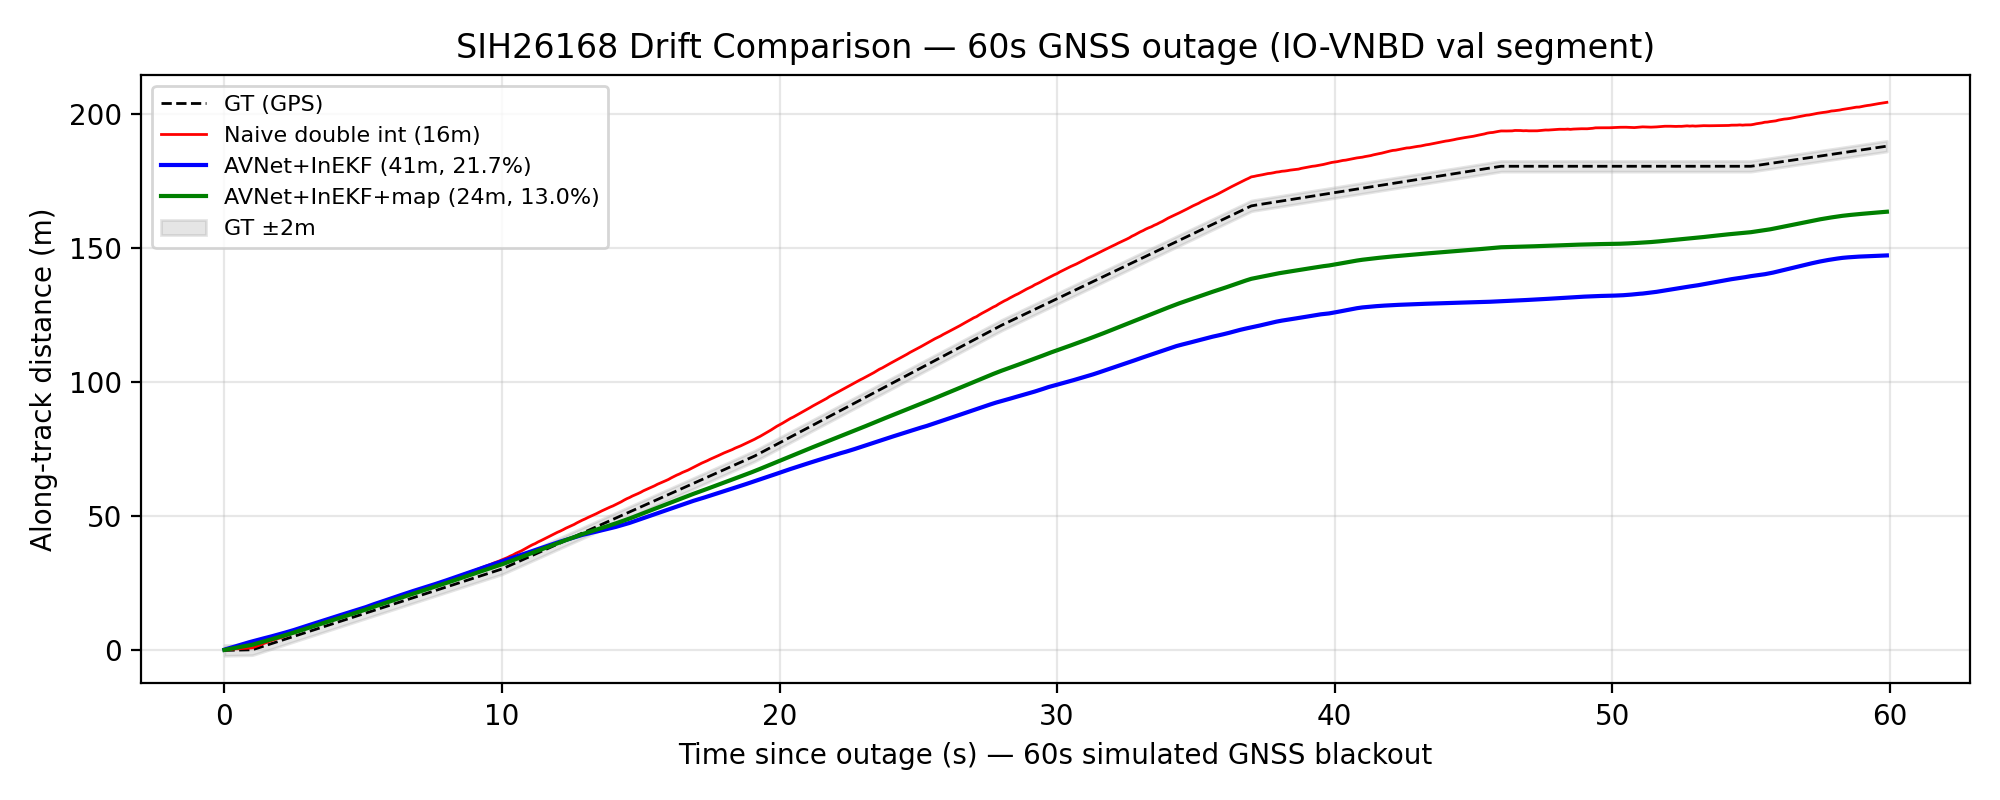

In [4]:
!PYTHONPATH=. python python/eval_drift.py --model experiments/checkpoints/model_avnet_stage1.p --plot reports/drift_plot.png
from IPython.display import Image; Image("reports/drift_plot.png")

In [5]:
!PYTHONPATH=. python python/export_tflite.py --model experiments/checkpoints/model_avnet_stage1.p --out model.tflite --onnx model.onnx
!ls -lh model.* scaler.json
!zip -r screening.zip model.tflite scaler.json reports/drift_plot.png python/scaler.json
!ls -lh screening.zip

[load] experiments/checkpoints/model_avnet_stage1.p
[model] 460,136 params, est FP32 1.84 MB FP16 0.92 MB
/content/sih26168/python/export_tflite.py:21: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0829 21:13:03.461000 5794 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
[torch.onnx] Obtain model graph for `AVNetLite([...]` with `torch.export.export(..., strict=False)`...
/usr/li